**Problem set 2 :** Term deposit prediction using logistic regression

**Problem statement :** A banking institution aims to predict whether a customer will subscribe to a term deposit based on their demographic and banking information. The goal is to build a classification model using Logistic Regression and compare it with other models.

**Dataset description :** The data set that is used is the Bank Marketing Dataset, which contains 17 attributes. such as:
 1. Age
 2. Job
 3. Marital status
 4. Education
 5. Balance
 6. Contact details
 7. Previous campaign information

The target variable indicates whether the customer subscribed to a term deposit (yes/no).









In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.feature_selection import SelectKBest, chi2
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('dataset')

os.listdir('dataset')

Saving bank-data.zip to bank-data.zip


['bank-data', '__MACOSX']

In [ ]:
df = pd.read_csv('dataset/bank-data/bank-full.csv', sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


**Data Preprocessing :** In this step, the dataset is cleaned and prepared for modeling.

**Key steps performed :**
 1. Handling missing values (if any)
 2. Converting categorical variables into numerical format using encoding
 3. Feature engineering (e.g., handling pdays values)
 4. Splitting the dataset into training and testing sets

Preprocessing ensures that the data is suitable for machine learning algorithms.

In [ ]:
df = pd.get_dummies(df, drop_first=True)
print(df.shape)

(45211, 43)


In [ ]:
X = df.drop('y_yes', axis=1)
y = df['y_yes']

In [ ]:
print(df.columns)

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'education_secondary',
       'education_tertiary', 'education_unknown', 'default_yes', 'housing_yes',
       'loan_yes', 'contact_telephone', 'contact_unknown', 'month_aug',
       'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'poutcome_other', 'poutcome_success', 'poutcome_unknown', 'y_yes'],
      dtype='object')


In [ ]:
X['has_previous_contact'] = (X['pdays'] != -1).astype(int)
X['pdays'] = X['pdays'].replace(-1, 0)

X = X.clip(lower=0)

from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(score_func=chi2, k=15)
X_new = selector.fit_transform(X, y)

print(X.columns[selector.get_support()])

Index(['balance', 'duration', 'campaign', 'pdays', 'previous', 'job_retired',
       'job_student', 'housing_yes', 'contact_unknown', 'month_mar',
       'month_may', 'month_oct', 'month_sep', 'poutcome_success',
       'has_previous_contact'],
      dtype='object')


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Model Building**

In this project, multiple machine learning models were implemented and compared to evaluate their performance:

 1. Logistic Regression (baseline model)
 2. Decision Tree Classifier
 3. Random Forest Classifier
 4. Logistic Regression with L1 Regularization
 5. Logistic Regression with L2 Regularization

Logistic Regression is used as the primary model because it is simple, interpretable, and well-suited for binary classification problems.

Decision Tree and Random Forest models are included to compare performance with more complex, non-linear models.

Regularization techniques (L1 and L2) are applied to Logistic Regression to improve generalization and prevent overfitting.




In [ ]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("🔹 Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

🔹 Logistic Regression Results
Accuracy: 0.8424195510339489

Confusion Matrix:
 [[6713 1239]
 [ 186  905]]

Classification Report:
               precision    recall  f1-score   support

       False       0.97      0.84      0.90      7952
        True       0.42      0.83      0.56      1091

    accuracy                           0.84      9043
   macro avg       0.70      0.84      0.73      9043
weighted avg       0.91      0.84      0.86      9043



In [ ]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("\n🔹 Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, dt_pred))


🔹 Decision Tree Results
Accuracy: 0.8745991374543846


In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\n🔹 Random Forest Results")
print("Accuracy:", accuracy_score(y_test, rf_pred))


🔹 Random Forest Results
Accuracy: 0.9042353201371226


# **Training**

All models are trained using the training dataset.
The models learn patterns from customer data to predict whether a customer will subscribe to a term deposit.

In [ ]:
model_l1 = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
model_l1.fit(X_train, y_train)

LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear')

In [ ]:
model_l2 = LogisticRegression(penalty='l2', max_iter=1000)
model_l2.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# **Model Evaluation and Comparison**

The models are evaluated using:
 1. Accuracy
 2. Precision
 3. Recall
 4. F1-score
 5. ROC-AUC score

ROC curves are plotted to visually compare model performance.

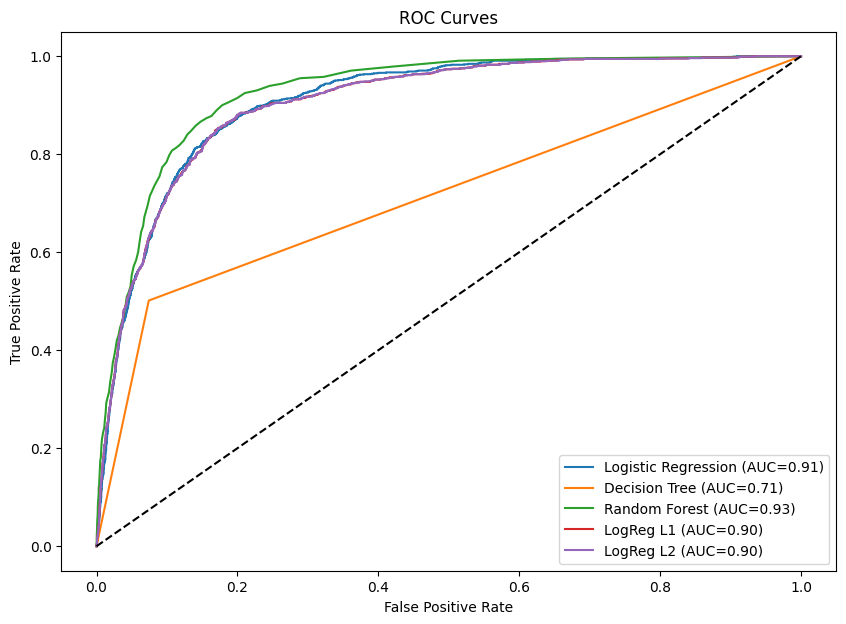

                 Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
0  Logistic Regression  0.842420   0.422108  0.829514  0.559505  0.907949
1        Decision Tree  0.874599   0.481091  0.501375  0.491023  0.713590
2        Random Forest  0.904235   0.673344  0.400550  0.502299  0.925555
3            LogReg L1  0.898817   0.654386  0.341888  0.449127  0.904573
4            LogReg L2  0.898817   0.654386  0.341888  0.449127  0.904538


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
import pandas as pd

models = {
    "Logistic Regression": model,
    "Decision Tree": dt,
    "Random Forest": rf,
    "LogReg L1": model_l1,
    "LogReg L2": model_l2
}

results = []
plt.figure(figsize=(10, 7))

for name, clf in models.items():
    y_pred = clf.predict(X_test)

    y_prob = clf.predict_proba(X_test)[:, 1] if hasattr(clf, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    class_labels = [k for k in report.keys() if k not in ['accuracy', 'macro avg', 'weighted avg']]
    positive_class = class_labels[-1]

    precision = report[positive_class]['precision']
    recall = report[positive_class]['recall']
    f1 = report[positive_class]['f1-score']

    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None

    results.append([name, acc, precision, recall, f1, auc])

    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

results_df = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1-score","ROC-AUC"])
print(results_df)

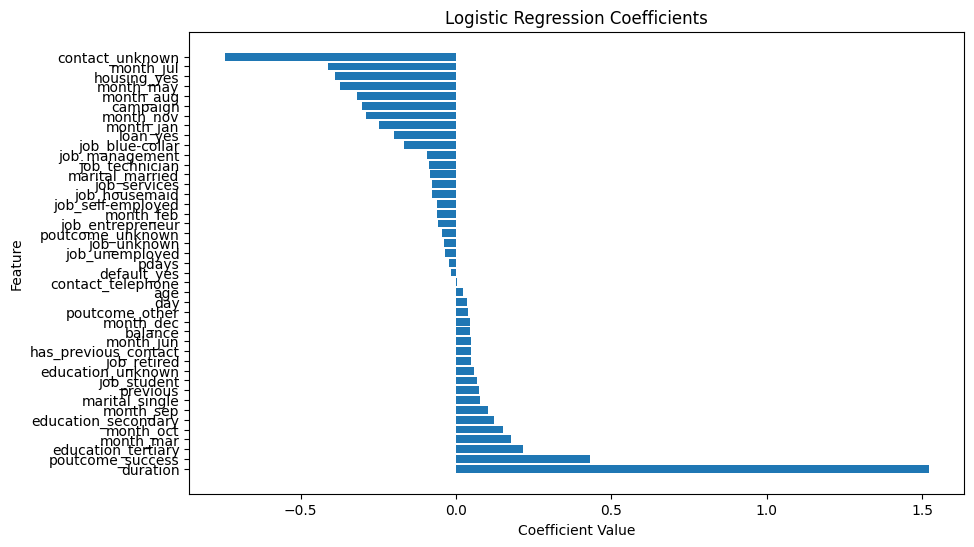

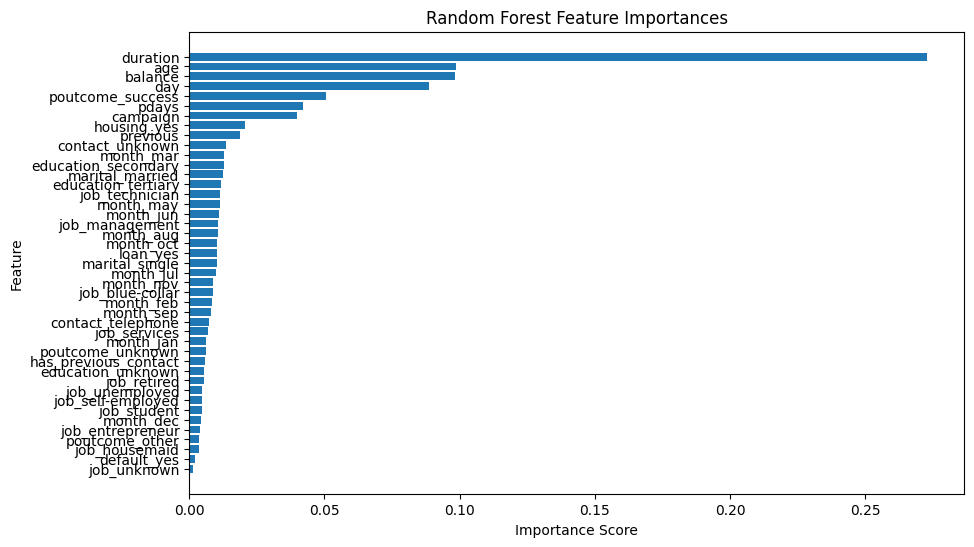

In [ ]:
import numpy as np

logreg_coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(logreg_coef["Feature"], logreg_coef["Coefficient"])
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

rf_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10,6))
plt.barh(rf_importances["Feature"], rf_importances["Importance"])
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

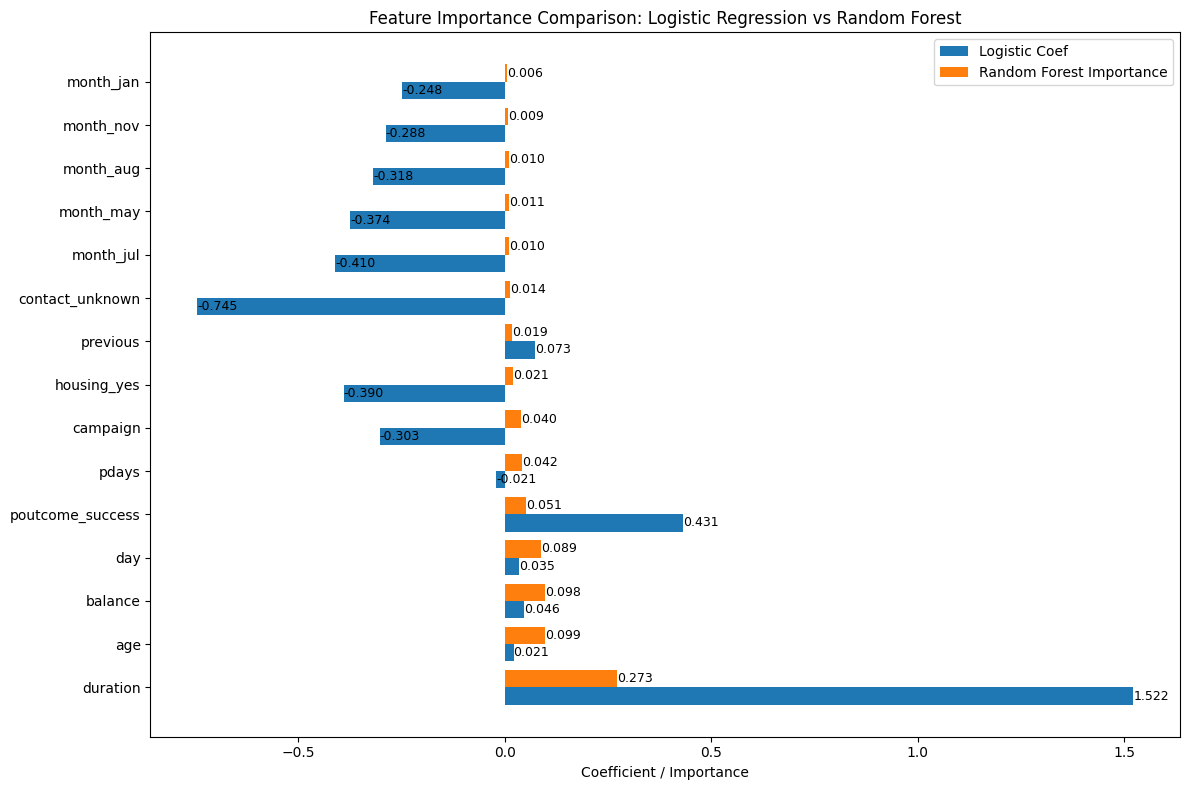

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

logreg_coef = pd.DataFrame({
    "Feature": X.columns,
    "LogReg_Coefficient": model.coef_[0]
})

rf_importances = pd.DataFrame({
    "Feature": X.columns,
    "RF_Importance": rf.feature_importances_
})

feature_compare = logreg_coef.merge(rf_importances, on="Feature")
feature_compare["LogReg_AbsCoef"] = feature_compare["LogReg_Coefficient"].abs()

top_features = pd.concat([
    feature_compare.nlargest(10, "RF_Importance"),
    feature_compare.nlargest(10, "LogReg_AbsCoef")
]).drop_duplicates("Feature")

fig, ax = plt.subplots(figsize=(12,8))
bar_width = 0.4
indices = np.arange(len(top_features))

bars1 = ax.barh(indices, top_features["LogReg_Coefficient"], bar_width, label="Logistic Coef")
bars2 = ax.barh(indices + bar_width, top_features["RF_Importance"], bar_width, label="Random Forest Importance")

ax.set_yticks(indices + bar_width/2)
ax.set_yticklabels(top_features["Feature"])
ax.set_xlabel("Coefficient / Importance")
ax.set_title("Feature Importance Comparison: Logistic Regression vs Random Forest")
ax.legend()

for bar in bars1:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2,
            f"{width:.3f}", ha='left', va='center', fontsize=9)

for bar in bars2:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2,
            f"{width:.3f}", ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8988167643481145

Confusion Matrix:
 [[7755  197]
 [ 718  373]]

Classification Report:
               precision    recall  f1-score   support

       False       0.92      0.98      0.94      7952
        True       0.65      0.34      0.45      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.88      0.90      0.88      9043



In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

print(feature_importance.sort_values(by='Coefficient', ascending=False))

                 Feature  Coefficient
3               duration     1.082421
40      poutcome_success     0.404352
21    education_tertiary     0.170072
34             month_mar     0.157459
33             month_jun     0.143447
37             month_oct     0.109953
20   education_secondary     0.104727
38             month_sep     0.099901
2                    day     0.084422
14           job_student     0.047493
19        marital_single     0.044994
29             month_dec     0.044829
39        poutcome_other     0.043760
11           job_retired     0.039322
22     education_unknown     0.038154
42  has_previous_contact     0.032437
1                balance     0.026962
0                    age     0.019180
6               previous     0.017830
23           default_yes    -0.009761
5                  pdays    -0.012741
41      poutcome_unknown    -0.017755
16        job_unemployed    -0.025304
26     contact_telephone    -0.029255
17           job_unknown    -0.031578
12     job_s

# **Findings**

 1. Multiple models were evaluated and compared
 2. Logistic Regression provided a strong baseline
 3. Random Forest / other models may perform better depending on results
 4. ROC curve analysis helped visualize performance differences

# **Conclusion**

Machine learning models can effectively predict customer subscription behavior.
Logistic Regression is simple and interpretable, while ensemble models may provide better performance.

In [ ]:
%%bash
git clone https://github.com/1234firuz/predictive_modeling-_assignment.git
cd predictive_modeling-_assignment
ls

Cloning into 'predictive_modeling-_assignment'...
